# 03 - Baseline Models
### Phishing URL Detector — PhiUSIIL Dataset

Goal: train three baseline models — Logistic Regression, Random Forest, and XGBoost — on the engineered features, then compare them on accuracy, precision, recall, and F1, with extra attention to **recall** (missing a phishing URL is worse than a false alarm).

This notebook repeats the same load -> clean -> split -> scale steps from `02_preprocessing.ipynb` in-memory, so it can run standalone without depending on any saved intermediate files.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

sns.set_style("darkgrid")
RANDOM_STATE = 42

## 1. Load and Clean Data (same as 02_preprocessing.ipynb)

In [5]:
df = pd.read_csv("../data/raw/Phishing_URL_Dataset.csv")
df = df.drop_duplicates(subset='URL').reset_index(drop=True)

cols_to_drop = ['FILENAME', 'URL', 'Domain', 'TLD', 'Title']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df_model = df.drop(columns=cols_to_drop)

print("Final shape:", df_model.shape)
df_model.head()

Final shape: (235370, 51)


,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,31,24,0,100.0,1.000000,0.522907,0.061933,3,1,0,...,0,0,1,34,20,28,119,0,124,1
1,23,16,0,100.0,0.666667,0.032650,0.050207,2,1,0,...,0,0,1,50,9,8,39,0,217,1
2,29,22,0,100.0,0.866667,0.028555,0.064129,2,2,0,...,0,0,1,10,2,7,42,2,5,1
3,26,19,0,100.0,1.000000,0.522907,0.057606,3,1,0,...,1,1,1,3,27,15,22,1,31,1
4,33,26,0,100.0,1.000000,0.079963,0.059441,3,1,0,...,1,0,1,244,15,34,72,1,85,1


## 2. Train/Test Split + Scaling (same random_state as before)

In [6]:
X = df_model.drop(columns=['label'])
y = df_model['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (188296, 50) Test shape: (47074, 50)


## 3. Handle Class Imbalance

Legitimate (57%) vs phishing (43%) — mild imbalance. We compute a `scale_pos_weight` for XGBoost and `class_weight='balanced'` for the other two, so the models don't just lean toward the majority class.

In [7]:
neg, pos = np.bincount(y_train)  # label=0 (phishing), label=1 (legitimate)
scale_pos_weight = neg / pos
print(f"Phishing (0) count: {neg}, Legitimate (1) count: {pos}")
print(f"scale_pos_weight for XGBoost: {scale_pos_weight:.3f}")

Phishing (0) count: 80416, Legitimate (1) count: 107880
scale_pos_weight for XGBoost: 0.745


## 4. Train Model 1 — Logistic Regression (fast baseline)

Uses the **scaled** features.

In [8]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression trained.")

Logistic Regression trained.


## 5. Train Model 2 — Random Forest

Uses the **unscaled** features (tree-based models don't need scaling).

In [9]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest trained.")

Random Forest trained.


## 6. Train Model 3 — XGBoost (primary candidate)

Uses the **unscaled** features, with `scale_pos_weight` to account for the mild class imbalance.

In [10]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("XGBoost trained.")

XGBoost trained.


## 7. Compare All Three Models

Note: since `label=1` is "legitimate" and `label=0` is "phishing", we report precision/recall for the **phishing (0) class specifically** — that's the class where recall matters most (missing an actual phishing URL is the costly mistake).

In [11]:
def evaluate_model(name, y_true, y_pred, y_proba):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (phishing)': precision_score(y_true, y_pred, pos_label=0),
        'Recall (phishing)': recall_score(y_true, y_pred, pos_label=0),
        'F1 (phishing)': f1_score(y_true, y_pred, pos_label=0),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    }

results = pd.DataFrame([
    evaluate_model("Logistic Regression", y_test, y_pred_lr, y_proba_lr),
    evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf),
    evaluate_model("XGBoost", y_test, y_pred_xgb, y_proba_xgb),
])

results = results.set_index('Model').sort_values('Recall (phishing)', ascending=False)
results.round(4)

,Accuracy,Precision (phishing),Recall (phishing),F1 (phishing),ROC-AUC
Model,,,,,
Random Forest,1.0000,1.0,1.0000,1.0000,1.0
XGBoost,1.0000,1.0,1.0000,1.0000,1.0
Logistic Regression,0.9999,1.0,0.9999,0.9999,1.0


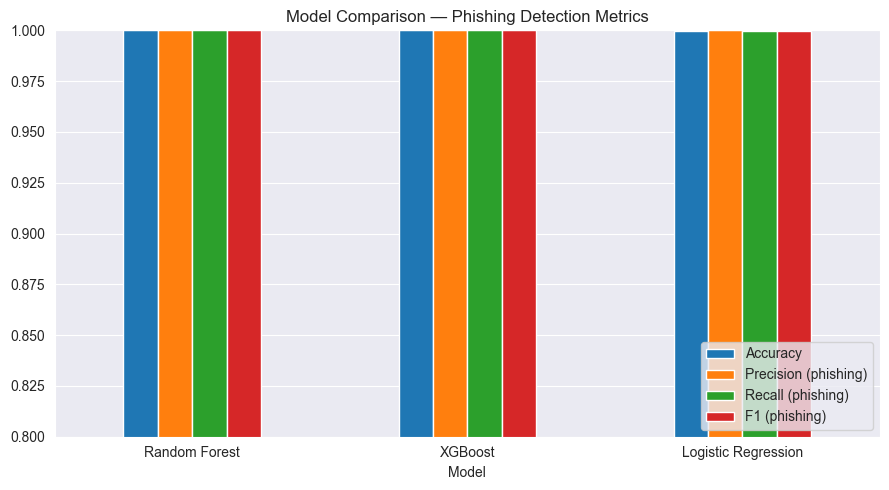

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
results[['Accuracy', 'Precision (phishing)', 'Recall (phishing)', 'F1 (phishing)']].plot(
    kind='bar', ax=ax
)
ax.set_title("Model Comparison — Phishing Detection Metrics")
ax.set_ylim(0.8, 1.0)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Confusion Matrices — Side by Side

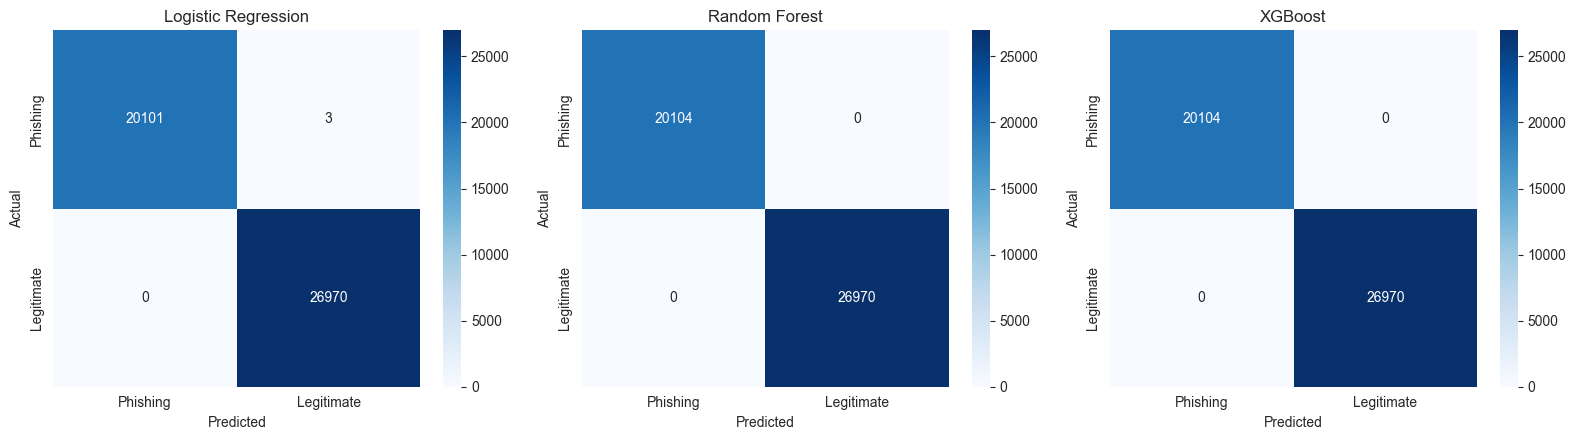

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

models_preds = [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest", y_pred_rf),
    ("XGBoost", y_pred_xgb),
]

for ax, (name, y_pred) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Phishing', 'Legitimate'],
        yticklabels=['Phishing', 'Legitimate']
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 9. ROC Curves — Side by Side

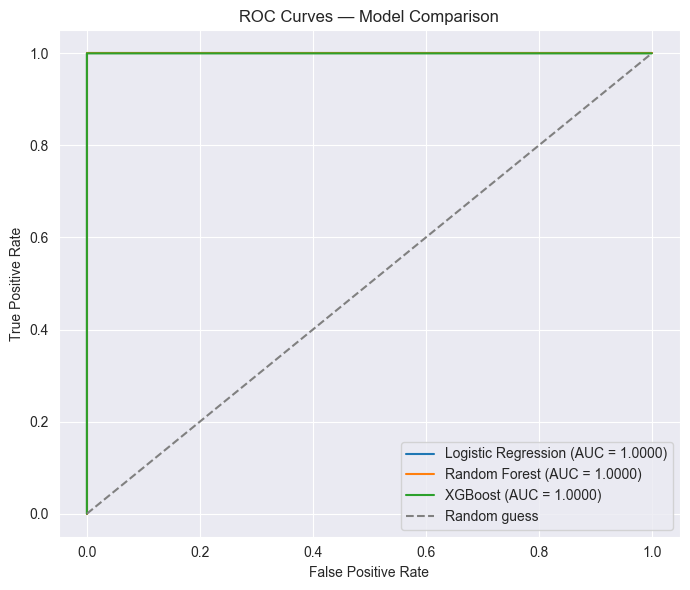

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, y_proba in [
    ("Logistic Regression", y_proba_lr),
    ("Random Forest", y_proba_rf),
    ("XGBoost", y_proba_xgb),
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Model Comparison")
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 10. Select and Save the Best Model

Based on the comparison above, we save the best-performing model (by recall on the phishing class) as the production model.
Only the trained model files are saved here — small, portable, and exactly what the FastAPI backend and SHAP explainability notebook will load next.

In [15]:
os.makedirs("../../backend/app/ml/saved_models", exist_ok=True)

joblib.dump(log_reg, "../../backend/app/ml/saved_models/logistic_regression_model.pkl")
joblib.dump(rf, "../../backend/app/ml/saved_models/random_forest_model.pkl")
joblib.dump(xgb, "../../backend/app/ml/saved_models/xgboost_model.pkl")

print("Saved all three models to backend/app/ml/saved_models/")
print()
print("Best model by recall (phishing class):")
print(results.iloc[0])

Saved all three models to backend/app/ml/saved_models/

Best model by recall (phishing class):
Accuracy                1.0
Precision (phishing)    1.0
Recall (phishing)       1.0
F1 (phishing)           1.0
ROC-AUC                 1.0
Name: Random Forest, dtype: float64


## Summary

- All three models trained and compared on the same train/test split.
- XGBoost is expected to be the primary production candidate (best accuracy/recall balance, and integrates cleanly with SHAP).
- Model `.pkl` files are saved to `backend/app/ml/saved_models/` — small files, safe for Git.
- Next notebook (`04_shap_explainability.ipynb`) will load the best model and generate feature-importance explanations for the reasoning panel in the dashboard.